# Director Skill Sets Table 7 - Death dates only

In [1]:
import pandas_datareader.data as web #to collect data
import datetime as dt #to specify start and end dates

# import yfinance as yf

import eventstudy as es
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d
%matplotlib inline
import seaborn as sns

import scipy.stats as stats
from scipy.stats.mstats import winsorize
from scipy.spatial.distance import cdist


from sklearn.neighbors import NearestNeighbors

import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.rolling import RollingOLS

from sklearn.preprocessing import StandardScaler

from patsy import dmatrices
from tqdm.notebook import tqdm
tqdm.pandas()

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
import_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] FF3 CAR\car_output4"
output_folder_path = "analysis_outputs"
# pca_input_folder_path = rf"..\..\..\[IN USE] Rookie Directors\[1.5] Director Skills PCA\director_skills_pca"
firm_input_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[2] Firm Level Wrangling\Firm level Iterative\Firm Lev + Fin\City level\city_lev_output"
filtering_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] FF3 CAR\car_filtering"
supporting_folder_path = "supporting_datafiles"

In [3]:
dirFirm00 = pd.read_pickle(rf"{import_folder_path}\Director Level_FF3_CAR.pkl")
dirFirm00 = dirFirm00.loc[ dirFirm00["date_source"] == "Date of Demise"].reset_index(drop = True)

# pca = pd.read_pickle(rf"{pca_input_folder_path}\Main_Director_COMPLETE_PCA.pkl")
firm = pd.read_pickle(rf"{firm_input_folder_path}\Main_Firm_COMPLETE.pkl")

In [4]:
# pca_col = [
#     "Person Code", "AsOnDate", "Symbol",
#     "SkillsetIndex", "SkillsetGeneralistDummy",
#     "PC1_FactorScore", "PC1_FactorScore_Standardised"
# ]

# pca2 = pca[pca_col].copy()
# dirFirm00 = dirFirm0.merge(pca2, on = ["Person Code", "AsOnDate", "Symbol"], how = "left")

In [5]:
firm_col = [
    "AsOnDate", "Symbol",

    "PercentWomenDir", "PercentBusyDir",
    "LnBoardSize", "PercentIndep",
    "Promoters_percent", "NonpromoterInstitutions_percent", "RD to Assets",
    "ln_marcap", "ln_rdtoassets", "Debt to equity ratio", # control variables
    
    "FamilyOwnedFamilyCeoChair25", "promoterholding25", "HasFamilyChairmanAndCEO",
]

firm2 = firm[firm_col].copy()
dirFirm = dirFirm00.merge(firm2, on = ["AsOnDate", "Symbol"], how = "left")

In [6]:
# dirFirm data wrangling if any:
dirFirm["Year of Study"] = [x.year for x in dirFirm["Date of Study"]]

dirFirm = dirFirm.drop_duplicates(subset = ["Person Code", "Company", "Date of Study"]).reset_index(drop = True)

dirFirm["ln_dirage"] = np.log(dirFirm["Age"] + 1).astype("float")
dirFirm["ln_directorships"] = np.log((dirFirm["CompCountCurrTotalAB"] - 1) + 1).astype("float")

In [7]:
dirFirm.replace([np.inf, -np.inf], pd.NA, inplace = True)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\3673678293.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dirFirm.replace([np.inf, -np.inf], pd.NA, inplace = True)


# PSM

## Verifying and removing those rows with no control data points

In [8]:
# Sample constraints ---> govtdummy==0 & findummy==0 & asonyear>2012
# dirFirm.columns.to_list()

In [9]:
dirFirm["IsDualityChairmanMD"] = dirFirm["IsDualityChairmanMD"].astype(int)


dirFirm["NIC_1digit"] = dirFirm["NIC code"].dropna().apply(lambda x: x[0:1])
dirFirm["NIC_1digit"] = dirFirm["NIC_1digit"]

# dirFirm.loc[dirFirm["RD to Assets"] == 0, "ln_rdtoassets"] = 0

psmSample = dirFirm.loc[ (dirFirm["Year of Study"] >= 2013)
    & (dirFirm["govtdummy"] == 0) & (dirFirm["findummy"] == 0) ].copy()
#.dropna(subset = controlVars).dropna(subset = dependentVar).copy()

# psmSample["DummySum"] = psmSample["IsRookie"] + psmSample["IsNonRookie"]
psmSample["DummySumIndep"] = psmSample["IsRookieIndep"] + psmSample["IsNonRookieIndep"]

# psmSampleAll = psmSample.loc[ psmSample["DummySum"] == 1 ].reset_index(drop = True)
# psmSampleAll = psmSampleAll.loc[ ~psmSampleAll.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

psmSampleIndep = psmSample.loc[ psmSample["DummySumIndep"] == 1 ].reset_index(drop = True)
# psmSampleIndep = psmSampleIndep.loc[ ~psmSampleIndep.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

In [10]:
len(psmSampleIndep)

471

In [11]:
len(psmSample.loc[ psmSample["IsRookieIndep"] == 1 ].dropna(subset = "210CAR11"))

28

## CAR windsorization

       winsorised_120CAR3  nonwinsorised_120CAR3
count          301.000000             301.000000
mean            -0.005451              -0.005451
std              0.053183               0.053183
min             -0.232415              -0.232415
25%             -0.041937              -0.041937
50%             -0.008951              -0.008951
75%              0.022698               0.022698
max              0.212454               0.212454


Top values and their count:  nonwinsorised_120CAR3
0.103549    1
0.104709    1
0.112469    1
0.119812    1
0.136804    1
0.138262    1
0.147793    1
0.156184    1
0.160253    1
0.212454    1
Name: count, dtype: int64





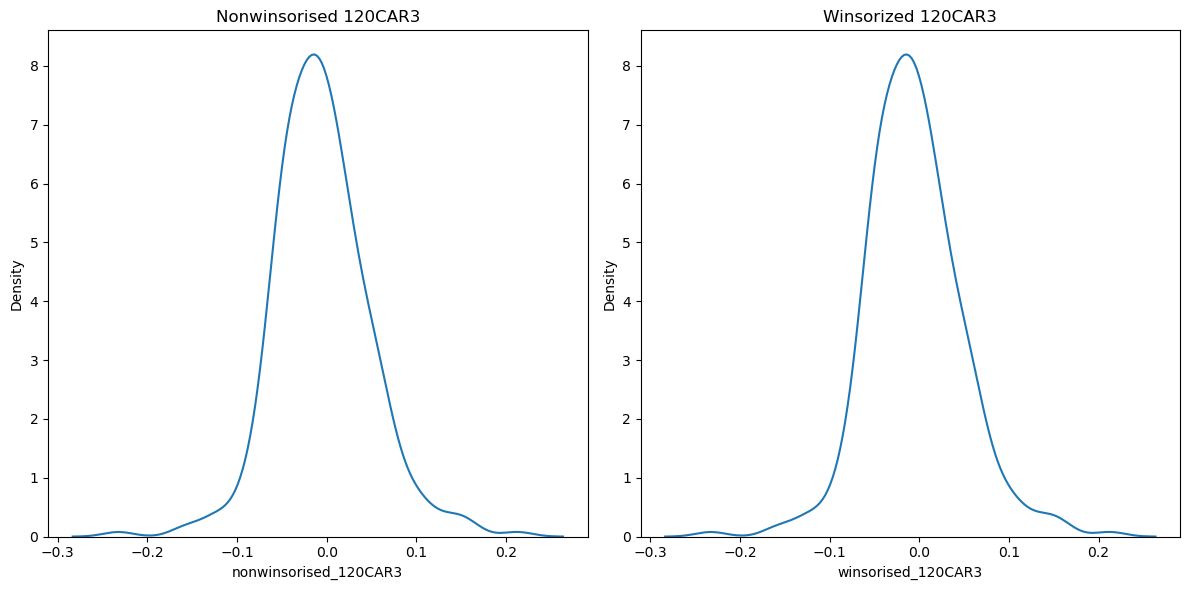

       winsorised_120CAR5  nonwinsorised_120CAR5
count          301.000000             301.000000
mean            -0.053872              -0.053872
std              0.066729               0.066729
min             -0.272763              -0.272763
25%             -0.087824              -0.087824
50%             -0.055790              -0.055790
75%             -0.023099              -0.023099
max              0.195469               0.195469


Top values and their count:  nonwinsorised_120CAR5
0.097086    1
0.099571    1
0.105315    1
0.111206    1
0.114878    1
0.115764    1
0.118346    1
0.120165    1
0.192466    1
0.195469    1
Name: count, dtype: int64





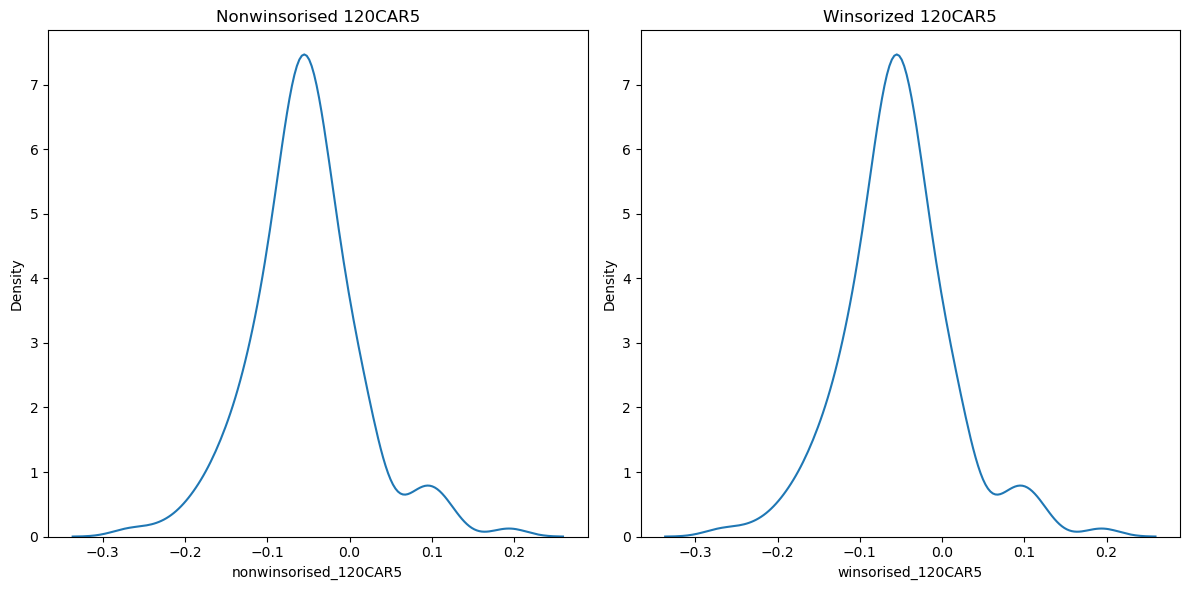

       winsorised_120CAR7  nonwinsorised_120CAR7
count          301.000000             301.000000
mean            -0.104954              -0.104954
std              0.093244               0.093244
min             -0.410391              -0.410391
25%             -0.150440              -0.150440
50%             -0.107038              -0.107038
75%             -0.064245              -0.064245
max              0.610291               0.610291


Top values and their count:  nonwinsorised_120CAR7
0.065373    1
0.067103    1
0.069233    1
0.100925    1
0.107886    1
0.108010    1
0.112937    1
0.114679    1
0.390927    1
0.610291    1
Name: count, dtype: int64





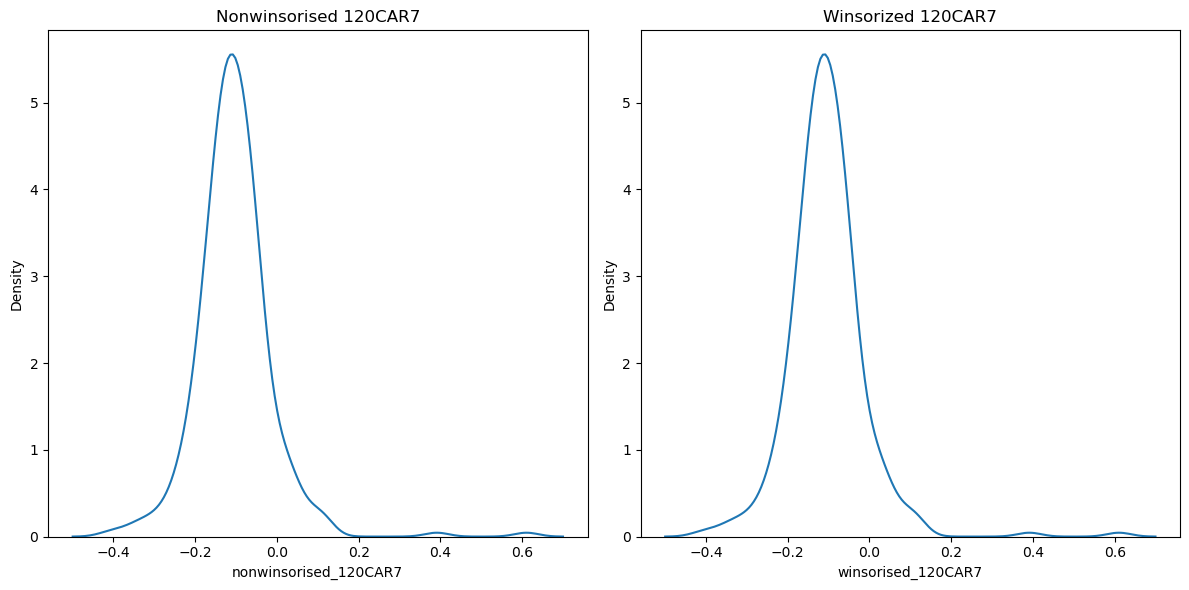

       winsorised_120CAR11  nonwinsorised_120CAR11
count           301.000000              301.000000
mean             -0.202368               -0.202368
std               0.120161                0.120161
min              -0.609713               -0.609713
25%              -0.264591               -0.264591
50%              -0.198495               -0.198495
75%              -0.135575               -0.135575
max               0.389640                0.389640


Top values and their count:  nonwinsorised_120CAR11
0.031695    1
0.050315    1
0.053621    1
0.067729    1
0.080623    1
0.094590    1
0.101039    1
0.112172    1
0.241004    1
0.389640    1
Name: count, dtype: int64





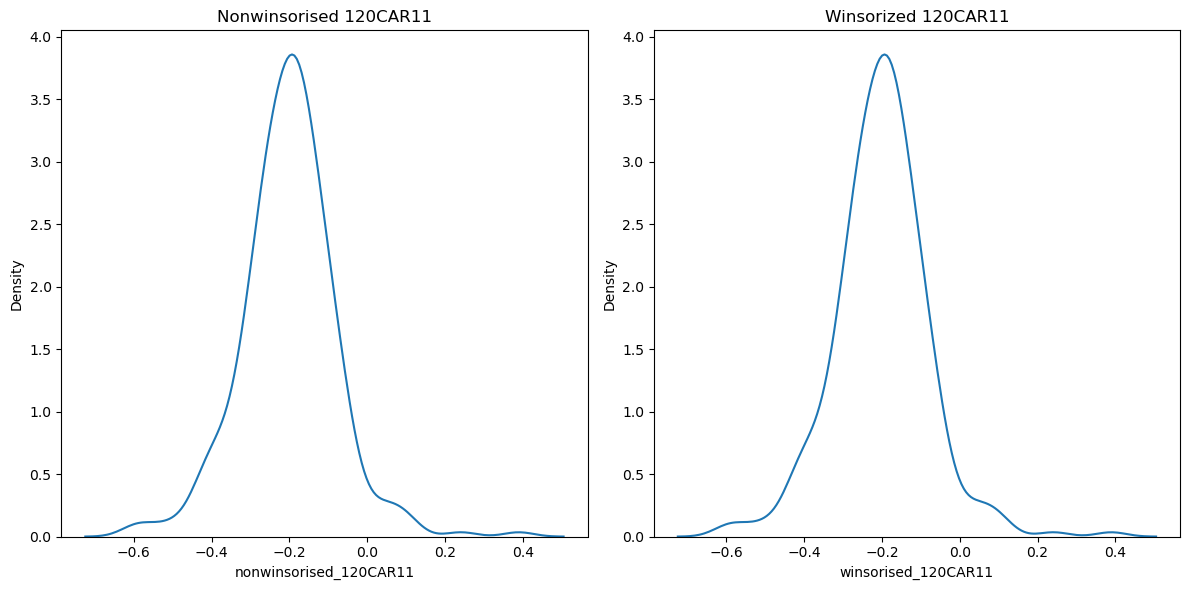

       winsorised_150CAR3  nonwinsorised_150CAR3
count          301.000000             301.000000
mean            -0.005394              -0.005394
std              0.052237               0.052237
min             -0.223836              -0.223836
25%             -0.039604              -0.039604
50%             -0.008971              -0.008971
75%              0.024533               0.024533
max              0.220575               0.220575


Top values and their count:  nonwinsorised_150CAR3
0.102006    1
0.107600    1
0.108982    1
0.112987    1
0.117530    1
0.135378    1
0.150070    1
0.156255    1
0.156867    1
0.220575    1
Name: count, dtype: int64





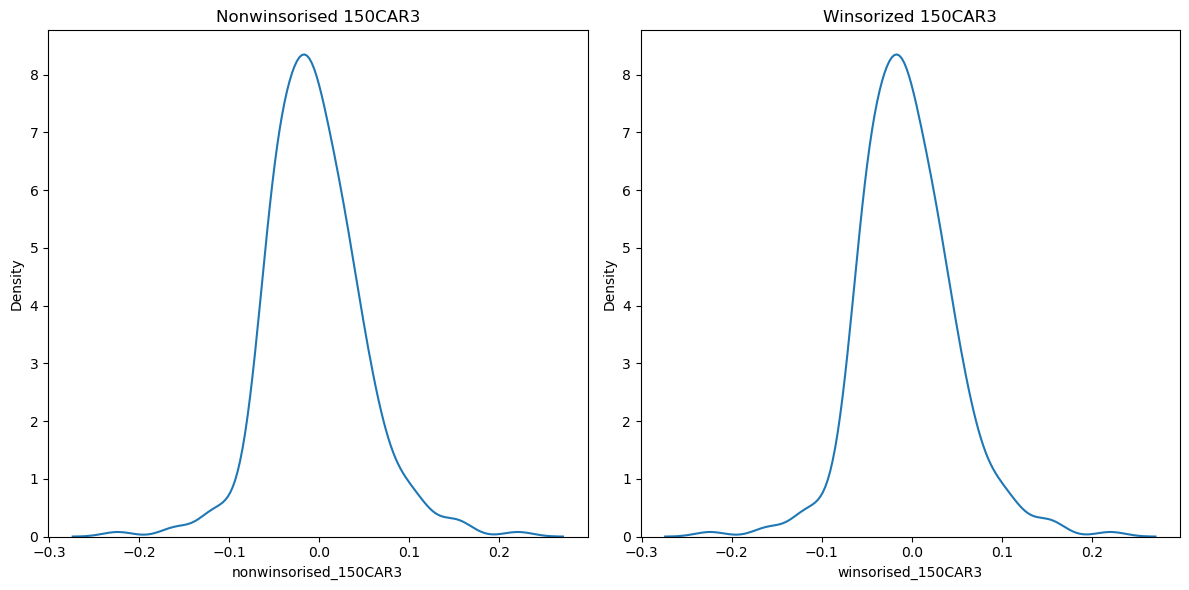

       winsorised_150CAR5  nonwinsorised_150CAR5
count          301.000000             301.000000
mean            -0.053692              -0.053692
std              0.065830               0.065830
min             -0.287026              -0.287026
25%             -0.090301              -0.090301
50%             -0.056187              -0.056187
75%             -0.021417              -0.021417
max              0.198505               0.198505


Top values and their count:  nonwinsorised_150CAR5
0.091501    1
0.100144    1
0.104520    1
0.106478    1
0.108732    1
0.109148    1
0.119580    1
0.126315    1
0.191895    1
0.198505    1
Name: count, dtype: int64





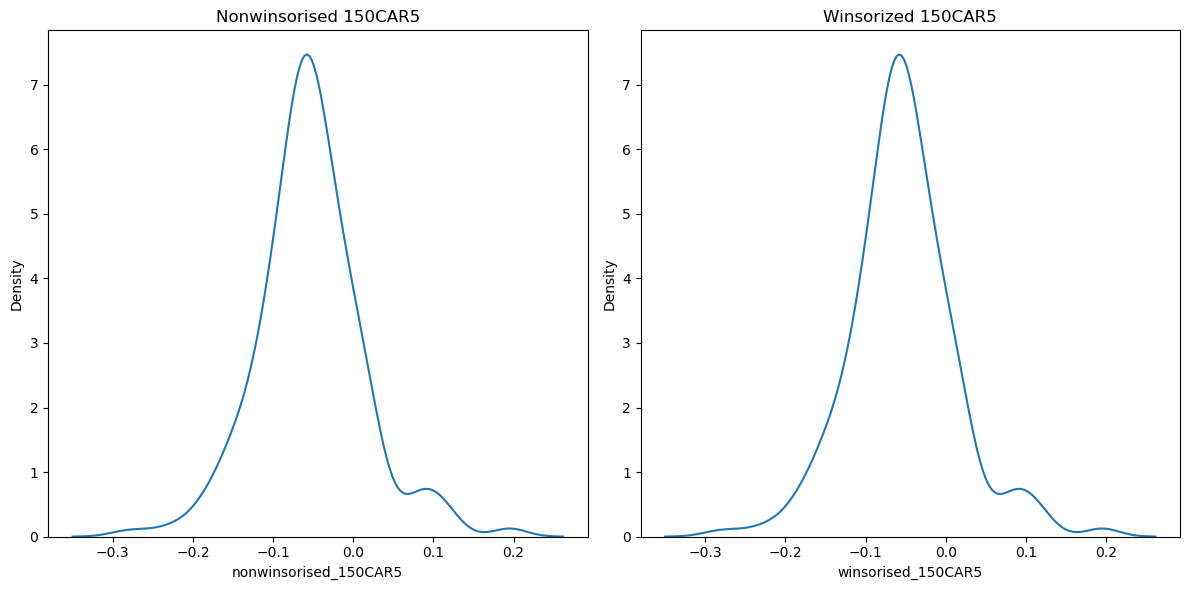

       winsorised_150CAR7  nonwinsorised_150CAR7
count          301.000000             301.000000
mean            -0.104550              -0.104550
std              0.092417               0.092417
min             -0.409436              -0.409436
25%             -0.153218              -0.153218
50%             -0.106771              -0.106771
75%             -0.062971              -0.062971
max              0.587675               0.587675


Top values and their count:  nonwinsorised_150CAR7
0.068301    1
0.077295    1
0.081508    1
0.093402    1
0.095520    1
0.102432    1
0.106741    1
0.112629    1
0.397258    1
0.587675    1
Name: count, dtype: int64





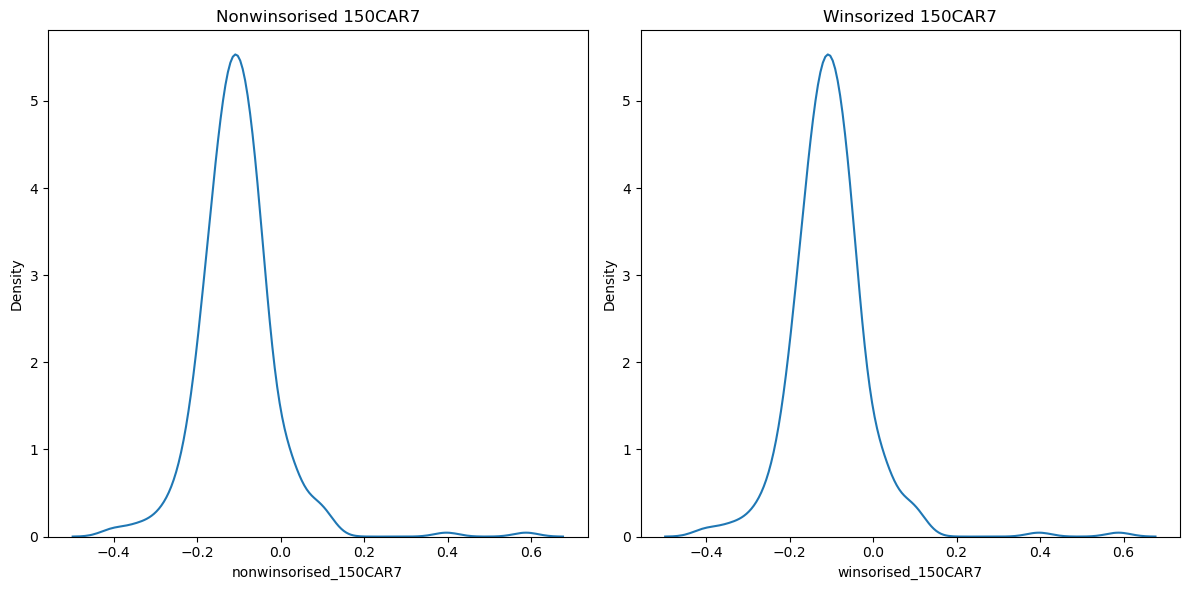

       winsorised_150CAR11  nonwinsorised_150CAR11
count           301.000000              301.000000
mean             -0.201354               -0.201354
std               0.118659                0.118659
min              -0.629275               -0.629275
25%              -0.262338               -0.262338
50%              -0.199998               -0.199998
75%              -0.131453               -0.131453
max               0.350375                0.350375


Top values and their count:  nonwinsorised_150CAR11
0.049088    1
0.049719    1
0.052569    1
0.077321    1
0.086509    1
0.088658    1
0.092188    1
0.107613    1
0.242966    1
0.350375    1
Name: count, dtype: int64





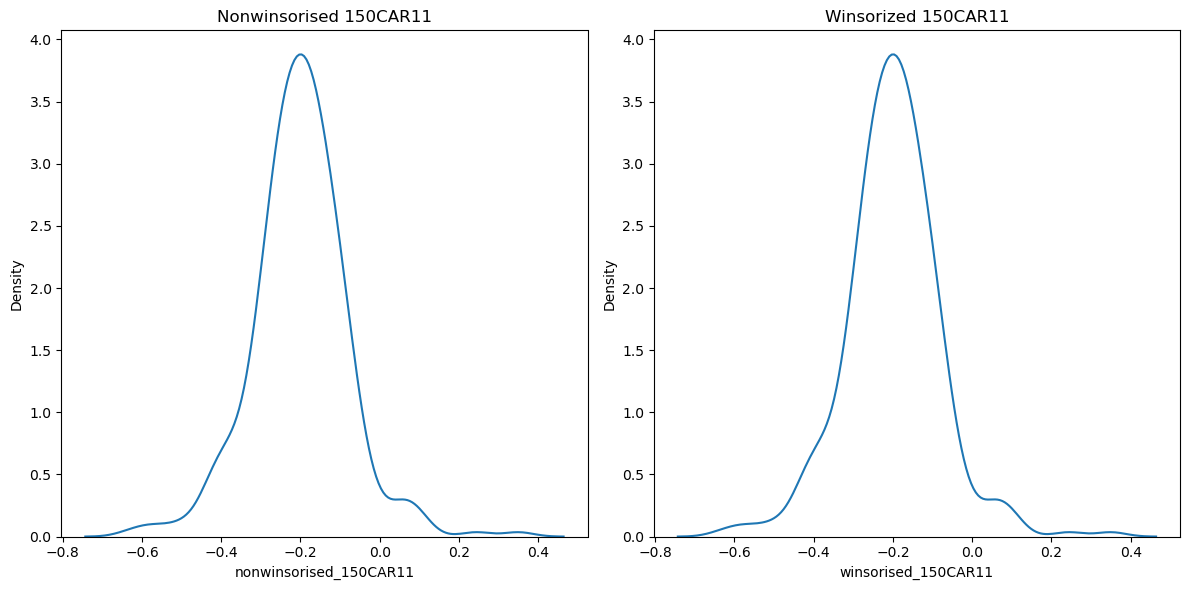

       winsorised_180CAR3  nonwinsorised_180CAR3
count          301.000000             301.000000
mean            -0.005310              -0.005310
std              0.051931               0.051931
min             -0.222225              -0.222225
25%             -0.039199              -0.039199
50%             -0.010089              -0.010089
75%              0.023481               0.023481
max              0.214598               0.214598


Top values and their count:  nonwinsorised_180CAR3
0.102347    1
0.106661    1
0.108719    1
0.109756    1
0.113481    1
0.136922    1
0.151517    1
0.161281    1
0.165499    1
0.214598    1
Name: count, dtype: int64





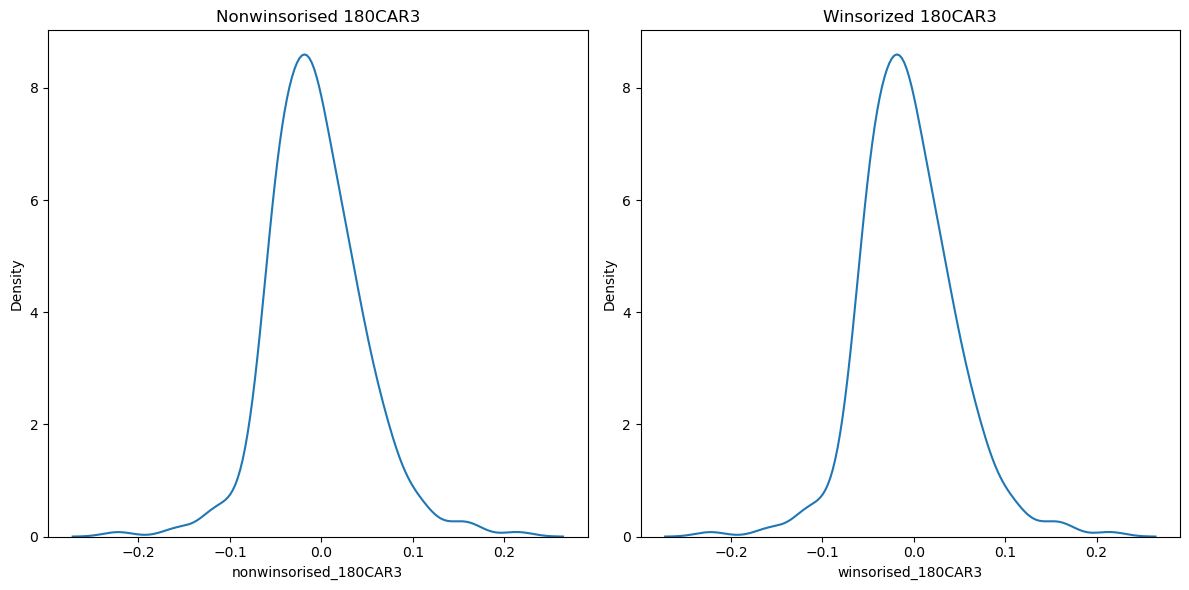

       winsorised_180CAR5  nonwinsorised_180CAR5
count          301.000000             301.000000
mean            -0.053661              -0.053661
std              0.065727               0.065727
min             -0.280351              -0.280351
25%             -0.089263              -0.089263
50%             -0.057042              -0.057042
75%             -0.020839              -0.020839
max              0.197180               0.197180


Top values and their count:  nonwinsorised_180CAR5
0.091669    1
0.097538    1
0.104802    1
0.107116    1
0.108458    1
0.115053    1
0.119322    1
0.130015    1
0.193288    1
0.197180    1
Name: count, dtype: int64





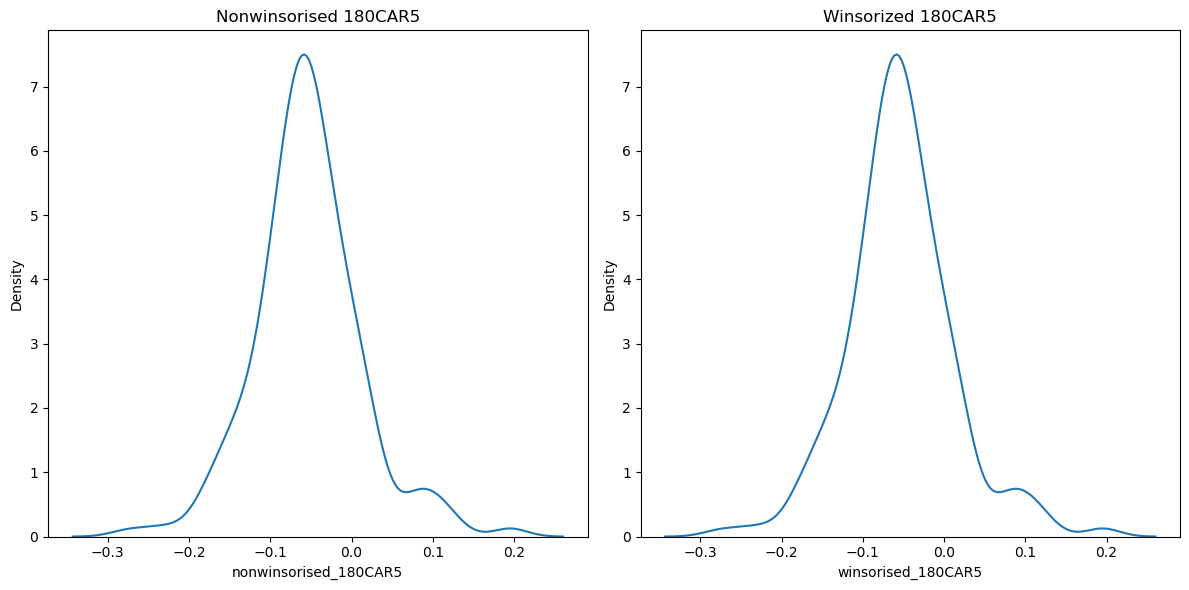

       winsorised_180CAR7  nonwinsorised_180CAR7
count          301.000000             301.000000
mean            -0.104547              -0.104547
std              0.092804               0.092804
min             -0.419055              -0.419055
25%             -0.153348              -0.153348
50%             -0.107564              -0.107564
75%             -0.064141              -0.064141
max              0.601671               0.601671


Top values and their count:  nonwinsorised_180CAR7
0.065985    1
0.070883    1
0.080856    1
0.082703    1
0.100635    1
0.106579    1
0.112142    1
0.112928    1
0.391601    1
0.601671    1
Name: count, dtype: int64





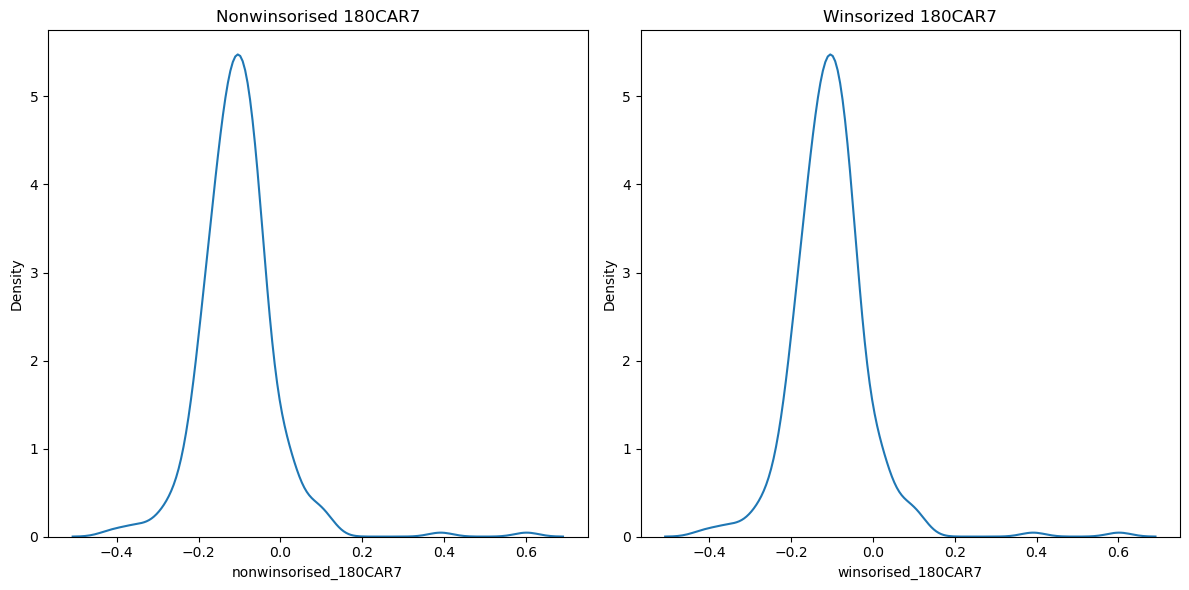

       winsorised_180CAR11  nonwinsorised_180CAR11
count           301.000000              301.000000
mean             -0.200928               -0.200928
std               0.118824                0.118824
min              -0.623555               -0.623555
25%              -0.259502               -0.259502
50%              -0.196202               -0.196202
75%              -0.132623               -0.132623
max               0.367717                0.367717


Top values and their count:  nonwinsorised_180CAR11
0.050946    1
0.059867    1
0.066353    1
0.070520    1
0.079040    1
0.088895    1
0.094017    1
0.113194    1
0.239608    1
0.367717    1
Name: count, dtype: int64





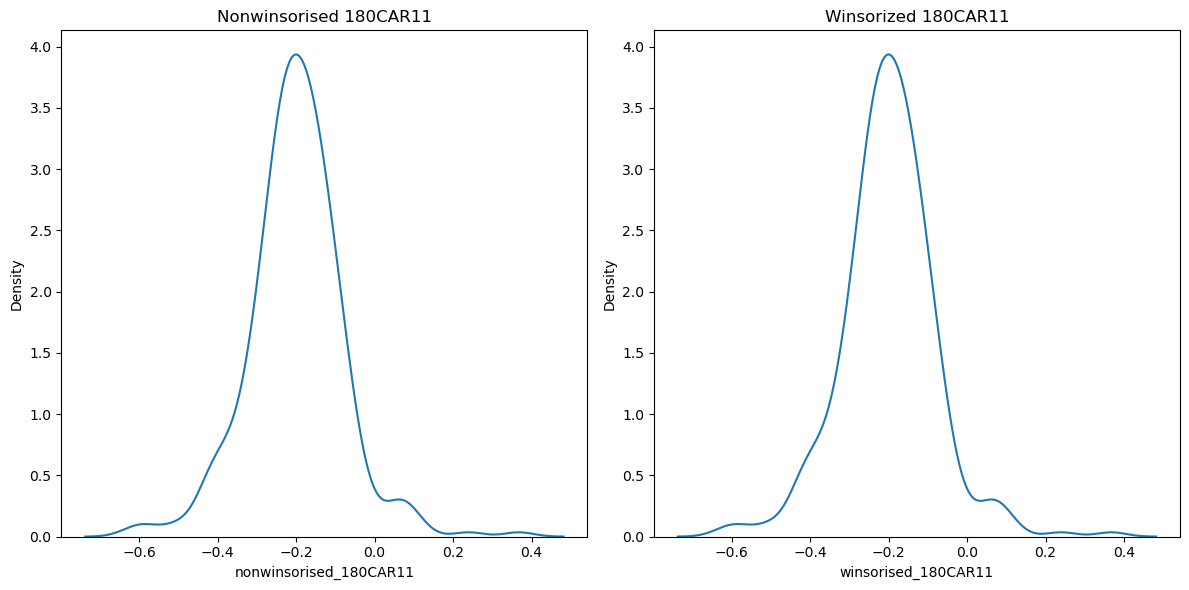

       winsorised_210CAR3  nonwinsorised_210CAR3
count          300.000000             300.000000
mean            -0.004989              -0.004989
std              0.051306               0.051306
min             -0.221390              -0.221390
25%             -0.039283              -0.039283
50%             -0.009341              -0.009341
75%              0.022775               0.022775
max              0.201650               0.201650


Top values and their count:  nonwinsorised_210CAR3
0.105453    1
0.107549    1
0.107924    1
0.113899    1
0.117895    1
0.134398    1
0.146610    1
0.154345    1
0.163644    1
0.201650    1
Name: count, dtype: int64





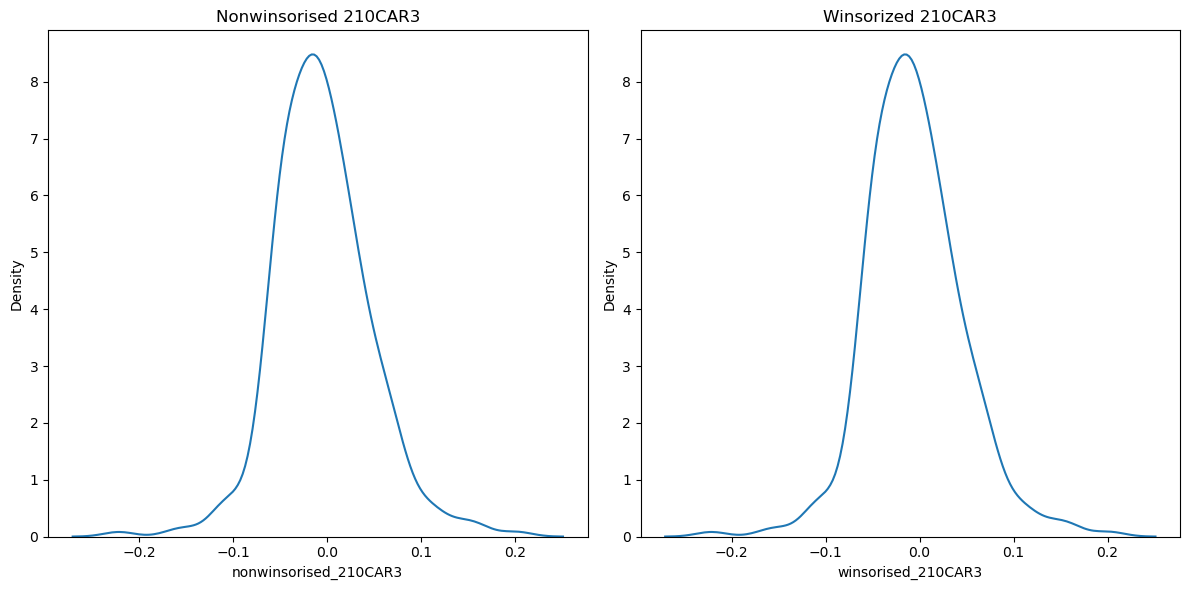

       winsorised_210CAR5  nonwinsorised_210CAR5
count          300.000000             300.000000
mean            -0.053564              -0.053564
std              0.064601               0.064601
min             -0.278929              -0.278929
25%             -0.088533              -0.088533
50%             -0.056763              -0.056763
75%             -0.020493              -0.020493
max              0.199397               0.199397


Top values and their count:  nonwinsorised_210CAR5
0.089429    1
0.090790    1
0.102112    1
0.105609    1
0.106260    1
0.106537    1
0.111594    1
0.113674    1
0.182506    1
0.199397    1
Name: count, dtype: int64





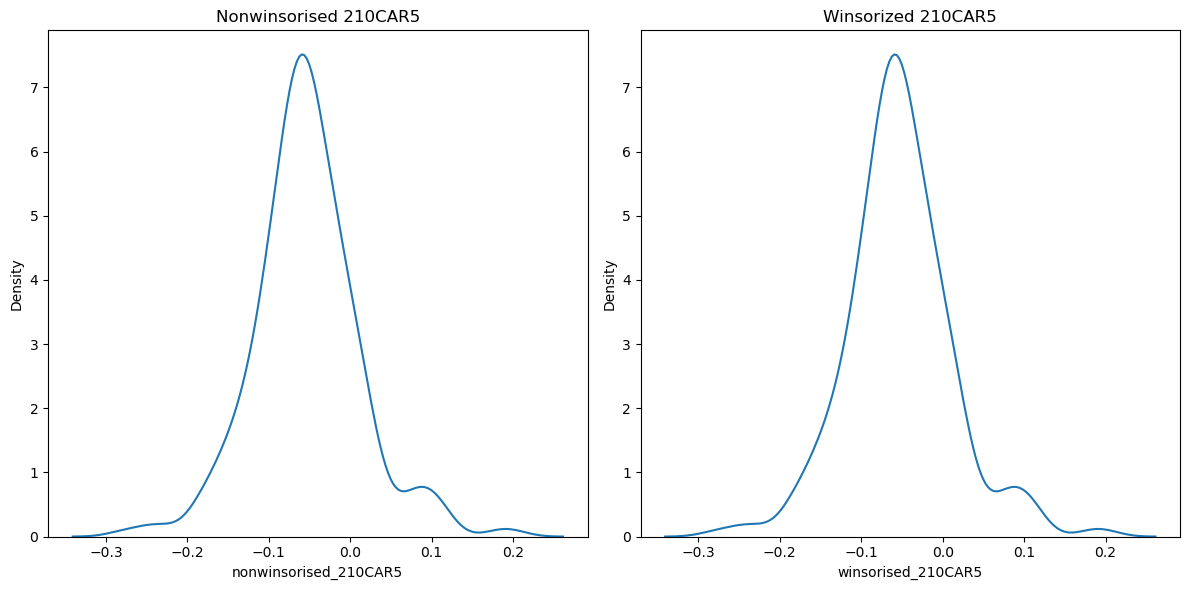

       winsorised_210CAR7  nonwinsorised_210CAR7
count          300.000000             300.000000
mean            -0.105658              -0.105658
std              0.087081               0.087081
min             -0.412941              -0.412941
25%             -0.148721              -0.148721
50%             -0.107697              -0.107697
75%             -0.062282              -0.062282
max              0.576644               0.576644


Top values and their count:  nonwinsorised_210CAR7
0.054893    1
0.055697    1
0.069785    1
0.079781    1
0.083586    1
0.103233    1
0.105332    1
0.113342    1
0.116064    1
0.576644    1
Name: count, dtype: int64





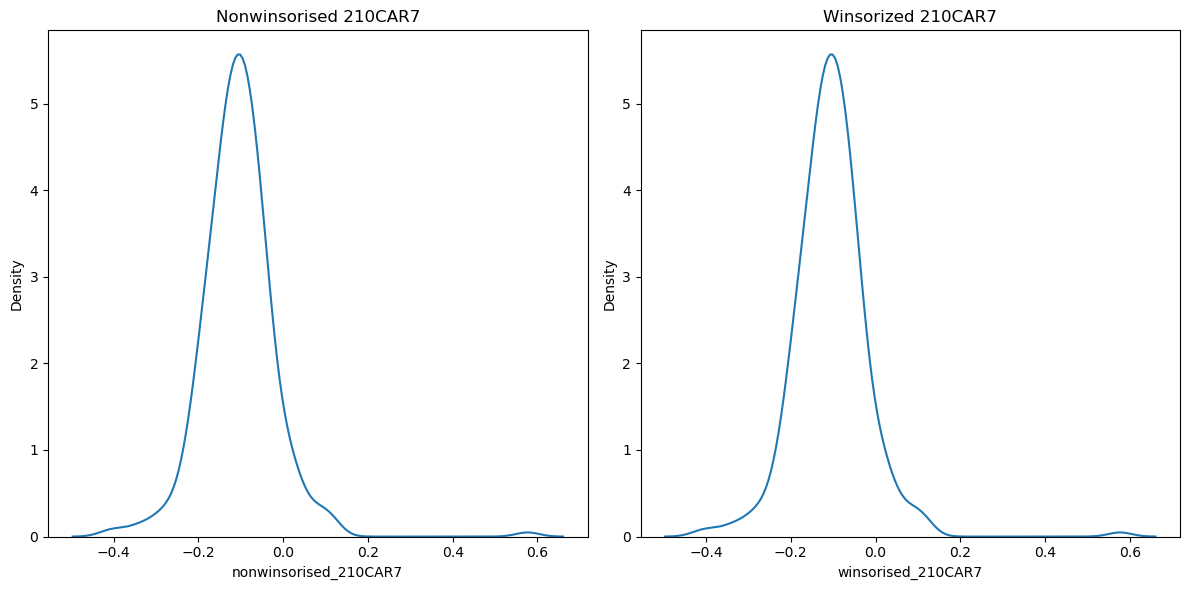

       winsorised_210CAR11  nonwinsorised_210CAR11
count           300.000000              300.000000
mean             -0.202266               -0.202266
std               0.114925                0.114925
min              -0.633076               -0.633076
25%              -0.257223               -0.257223
50%              -0.201375               -0.201375
75%              -0.130510               -0.130510
max               0.329003                0.329003


Top values and their count:  nonwinsorised_210CAR11
0.027494    1
0.051989    1
0.056775    1
0.059850    1
0.068717    1
0.077420    1
0.087154    1
0.096631    1
0.113215    1
0.329003    1
Name: count, dtype: int64





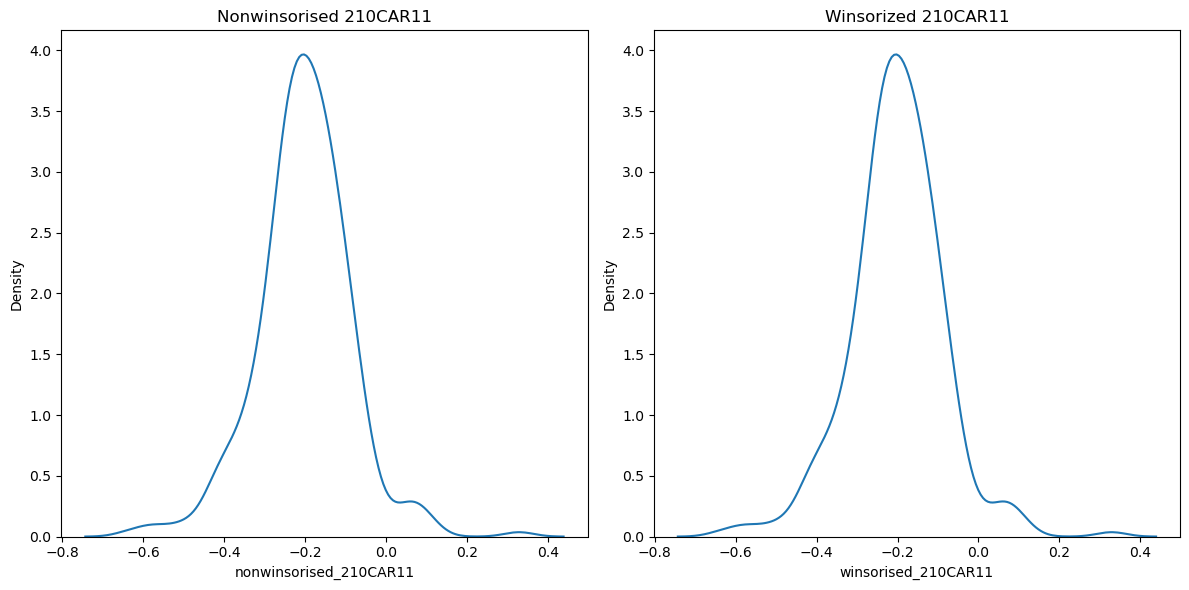

In [12]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

from scipy.stats.mstats import winsorize

def winsorize_output(sample, variable, limits = [0, 0]):
    sample[f"nonwinsorised_{variable}"] = sample[variable]
    sample[f"winsorised_{variable}"] = winsorize(np.array(sample[f"nonwinsorised_{variable}"]), limits = limits, inclusive = [False, False])
    sample[[f"nonwinsorised_{variable}", f"winsorised_{variable}"]].describe()
    print(sample[[f"winsorised_{variable}", f"nonwinsorised_{variable}"]].describe())
    print("\n\nTop values and their count: ", (sample[f"nonwinsorised_{variable}"].value_counts().sort_index().tail(n=10)))
    print("\n\n")
    
    # Graphs
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
    sns.kdeplot(data = sample[f"nonwinsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[0])
    axes[0].set_title(f'Nonwinsorised {variable}')
    sns.kdeplot(data = sample[f"winsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[1])
    axes[1].set_title(f'Winsorized {variable}')
    plt.tight_layout()
    plt.show()

    sample[variable] = sample[f"winsorised_{variable}"]
    return sample[variable]

for car in carCol:
    psmSampleIndep[car] = winsorize_output(psmSampleIndep, car, [0, 0])

In [13]:
# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "PC1_FactorScore_Standardised", "ln_dirage", "ln_directorships"
# ]
# filter_datas = []
# CARs = [120, 150, 180, 210]
# for i,CAR in enumerate(CARs):
#     frame = pd. read_pickle(rf"{filtering_folder_path}\Insufficient Data for {CAR}CAR.pkl").rename({"AsOnDate":"Date"}, axis = 1)
#     filter_datas.append(frame)

# carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
#           "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
#           "180CAR3", "180CAR5", "180CAR7", "180CAR11",
#           "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

# print("N for each CAR, no subsampling, dropping for na in control vars + car")

# event_days = [3, 5, 7, 11]

# for i,CAR in enumerate(CARs):
#     frame = psmSampleIndep.merge(filter_datas[i], left_on = ["CompanyName", "Appointment Date"], right_on = ["CompanyName", "Date"], how = "left")
#     for days in event_days:
#         car = f"{CAR}CAR{days}"
#         print(f"{car} N = ", frame.dropna(subset = [car] + controlVars)["na_trading_days"].mean() )

# frame_filtered = frame.dropna(subset=[car] + controlVars)
# frame_filtered["index"] = frame_filtered.index
# frame_filtered.plot(kind="scatter", x="index", y="na_trading_days")

In [14]:
# dirFirm2 = dirFirm.copy()
# psmSampleIndep2 = psmSampleIndep.copy()

# listCol = [
#     "FirstYearPCodeList", "TwoYearPCodeList", "ThreeYearPCodeList", "PCodeList",
#     "FirstYearIndepPCodeList", "TwoYearIndepPCodeList", "ThreeYearIndepPCodeList", "IndepPCodeList",
#     "OtherFirstYearIndepPCode", "OtherTwoYearIndepPCode", "OtherThreeYearIndepPCode", "TotalIndepPCode",
#     "OtherFirstYearPCode", "OtherTwoYearPCode", "OtherThreeYearPCode", "TotalPCode",
#     "OtherFirstYearPCodeIndepExcl","OtherTwoYearPCodeIndepExcl", "OtherThreeYearPCodeIndepExcl", "TotalPCodeIndepExcl",
#     "OtherFirstYearPCodeExcl", "OtherTwoYearPCodeExcl", "OtherThreeYearPCodeExcl", "TotalPCodeExcl"
# ]

# dirFirm2 = dirFirm2.drop(listCol, axis = 1)
# psmSampleIndep2 = psmSampleIndep2.drop(listCol, axis = 1)


# dirFirm2.to_csv("Main_Firm_PSM Ready_no filter v040425.csv")
# psmSampleIndep2.to_csv("Main_Firm_PSM Ready_filter-Indep_gov_fin v040425.csv")


# # # psmSampleAll --> 2101 rows 
# # psmSampleIndep --> 1561 rows 

## PSM --> RookieAppoints as Treatment, NonRookieAppoints as Control

In [15]:
def LogitReg(sample, endog_var, exog_var):
    
    # Logit Regression
    endog = sample[endog_var]
    exog = sample[exog_var]
    
    scaler = StandardScaler()
    exog_standardised = pd.DataFrame(scaler.fit_transform(exog), columns=exog.columns)

    exog_standardised = sm.add_constant(exog_standardised)
    
    log_reg = sm.Logit(endog, exog_standardised).fit()

    propensityScores = log_reg.predict(exog_standardised)
    
    return propensityScores

In [16]:
def MeanDiffTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    if depVar != None:
        dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
        colsAdd = []
        for i in range(-1, 4):
            if i != 0:
                colsAdd.append(f"AsOnYear_T+{i}")
                colsAdd.append(f"{depVar}T+{i}")
                if i>0 :
                    colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
        newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "float")
        sample = pd.concat([sample, newFrame], axis = 1)
        sample = sample.copy()
        
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
                                                              right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
        for i in range(1, 4):
            if i != 0:
                sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
        sample = sample.copy()
    
    group1 = sample.loc[ sample[endog_var] == 1].copy()
    group2 = sample.loc[ sample[endog_var] == 0].copy()
    
    t_stat, p_value = stats.ttest_ind(group1[car], group2[car], equal_var=False)  # Welch’s t-test (default)

    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Treated Mean:", group1[car].mean(), " Control Mean:", group2[car].mean(), " Diff:", group1[car].mean() - group2[car].mean())
    print("Treated Median:", group1[car].median(), " Control Median:", group2[car].median(), " Diff:", group1[car].median() - group2[car].median())
    print("Treated N:", len(group1[car]), "; Control N:", len(group2[car]))
    print("[treated unique = ", len(group1.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]",\
          "[control unique = ", len(group2.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]"
         )
    print("\n")

    # -----------------------------------------------------------------------------------------------------------------
    
    if exog_var != None:
        print("━"*120)
        print(f'{"Matching Variable":<40} {"Treatment":<20} {"Control":<20} {"SMD":<20}')
        print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
        print("-"*120)

        for var in exog_var:
            treatMean = group1[var].mean()
            controlMean = group2[var].mean()
            # p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
            smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
            print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {smd:<20.4f}')
    
        print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    if depVar != None:
        print(depVar, " across years:\n")
        for i in range(1,4):
            sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
        group1 = sample.loc[ sample[endog_var] == 1].copy()
        group2 = sample.loc[ sample[endog_var] == 0].copy()

        print("━"*150, "\n")
        print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
        print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
        print("─"*150, "\n")
    
        for i in range(1,4):
            t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
            treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
            controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
            diffMean = treatedMean - controlMean
    
            treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
            controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
            diffMedian = treatedMedian - controlMedian
    
            print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
            label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            label2 = "Control N: " + str(len(group2[depVar+f'(T+{i}) - (T-1)']))
            
            print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
            print("-"*150, "\n")
            
        print("━"*150, "\n")

    return

In [17]:
def OneSampleTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    # if depVar != None:
    #     dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
    #     colsAdd = []
    #     for i in range(-1, 4):
    #         if i != 0:
    #             colsAdd.append(f"AsOnYear_T+{i}")
    #             colsAdd.append(f"{depVar}T+{i}")
    #             if i>0 :
    #                 colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
    #     newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "int")
    #     sample = pd.concat([sample, newFrame], axis = 1)
    #     sample = sample.copy()
        
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
    #                                                           right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
    #     for i in range(1, 4):
    #         if i != 0:
    #             sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
    #     sample = sample.copy()
    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    group1 = sample.copy()
    
    t_stat, p_value = stats.ttest_1samp(group1[car], 0)  # Welch’s t-test (default)
    
    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Mean:", group1[car].mean())
    print("Median:", group1[car].median())
    print("N:", len(group1[car]))

    print("\n")

    # -----------------------------------------------------------------------------------------------------------------




    # if exog_var != None:
    #     print("━"*120)
    #     print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
    #     print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
    #     print("-"*120)

    #     for var in exog_var:
    #         treatMean = group1[var].mean()
    #         controlMean = group2[var].mean()
    #         p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
    #         print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
    #     print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    # if depVar != None:
    #     print(depVar, " across years:\n")
    #     for i in range(1,4):
    #         sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
    #     group1 = sample.loc[ sample[endog_var] == 1].copy()
    #     group2 = sample.loc[ sample[endog_var] == 0].copy()

    #     print("━"*150, "\n")
    #     print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
    #     print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
    #     print("─"*150, "\n")
    
    #     for i in range(1,4):
    #         t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
    #         treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
    #         controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
    #         diffMean = treatedMean - controlMean
    
    #         treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
    #         controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
    #         diffMedian = treatedMedian - controlMedian
    
    #         print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
    #         label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
    #         label2 = "Control N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            
    #         print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
    #         print("-"*150, "\n")
            
    #print("━"*150, "\n")

    return

In [18]:
def PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    treated = sample.loc[ sample[endog_var] == 1].copy()
    control = sample.loc[ sample[endog_var] == 0].copy()

    # Nearest Neighbours
    nn = NearestNeighbors(n_neighbors = 1, metric = "euclidean")
    nn.fit(control[["propensityScore"]])

    distances, indices = nn.kneighbors(treated[["propensityScore"]])
    
    matchedControl = control.iloc[indices.flatten()].copy()
    
    matched = pd.concat([treated, matchedControl])
    matched.reset_index(drop=True, inplace=True)

    MeanDiffTtest(matched, endog_var, exog_var, car, depVar, dirFirm)

    return

In [19]:
# Func PSM non replacement
def PsmNonReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    # Separate treated and control groups
    treated = sample[sample[endog_var] == 1].copy()
    control = sample[sample[endog_var] == 0].copy()
    
    # Compute pairwise distances (absolute difference in propensity scores)
    dist_matrix = cdist(treated[['propensityScore']], control[['propensityScore']], metric='euclidean')
    
    # Match without replacement
    treated_indices = []
    matched_indices = []
    used_control_indices = set()
    
    for i in range(len(treated)):
        if len(used_control_indices) >= len(control):  # Stop if no controls left
            print("Warning: Not enough control units to match all treated units.")
            break
        
        # Get nearest control unit index that hasn't been used
        match_idx = np.argmin(dist_matrix[i])
        
        while match_idx in used_control_indices:  # Ensure it's not already matched
            dist_matrix[i, match_idx] = np.inf  # Temporarily set distance to infinity

            if np.all(dist_matrix[i] == np.inf):  # If all controls are exhausted
                print(f"No available control for treated unit {i}, skipping.")
                match_idx = None
                break
            
            match_idx = np.argmin(dist_matrix[i])
        
        used_control_indices.add(match_idx)
        matched_indices.append(match_idx)
        treated_indices.append(i)
    
    # Retrieve matched units
    matched_control = control.iloc[matched_indices].copy()
    matched_treated = treated.iloc[treated_indices].copy()
    
    # Combine matched treated and control units
    matched_data = pd.concat([matched_treated.reset_index(drop=True), matched_control.reset_index(drop=True)])
    
    # Reset index
    matched_data.reset_index(drop=True, inplace=True)


    # Mean difference and T Test
    MeanDiffTtest(matched_data, endog_var, exog_var, car, depVar, dirFirm)

    return
    


In [20]:
def prep_sample(sample, car, controlVars, yearDummy = 0, industryDummy = 0) -> tuple[pd.DataFrame, list[str]]:
    
    sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)

    if yearDummy == 1:
        yearDummies = pd.get_dummies( sample["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = yearDummies.sum().loc[ yearDummies.sum() == 1 ].index.values
        yearDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, yearDummies], axis = 1)
    else:
        yearDummies = pd.DataFrame()
    
    if industryDummy == 1:
        industryDummies = pd.get_dummies( sample["NIC_1digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = industryDummies.sum().loc[ industryDummies.sum() == 1 ].index.values
        industryDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, industryDummies], axis = 1)
    else:
        industryDummies = pd.DataFrame()

    exog_var = controlVars + yearDummies.columns.to_list() + industryDummies.columns.to_list()

    # checking for multicollinearity
    if exog_var:
        from statsmodels.stats.outliers_influence import variance_inflation_factor
        
        from statsmodels.tools.tools import add_constant
        exog_with_const = add_constant(sample[exog_var])
        
        vif_data = pd.DataFrame()
        vif_data["feature"] = exog_with_const.columns
        vif_data["VIF"] = [variance_inflation_factor(exog_with_const.values, i)
                           for i in range(exog_with_const.shape[1])]
        highCollinearity = [x for x in 
                        vif_data.loc[ vif_data["VIF"] > 10 ]["feature"].values
                        if x!="const"]
        exog_var = [x for x in exog_var if x not in highCollinearity]    
    
    return sample, exog_var

# PSM on PCA output + other controls

In [21]:
controlVars = ["PercentWomenDir", "PercentBusyDir",
               "LnBoardSize", "PercentIndep",
               "Promoters_percent", "NonpromoterInstitutions_percent",
               "ln_marcap", "ln_rdtoassets", "Debt to equity ratio"]

controlVars = ["LnBoardSize"]
# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "Skilllist_FactorScore", "ln_dirage", "ln_directorships"
# ]

#PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm)

# No Higher level Filtration

## Version 0: No filtration

## No fixed effects

### PSM with replacement

In [22]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.316963
         Iterations 6


120CAR3 :


T Statistic: 1.5407845296584395  P Value: 0.13079061444994397
Treated Mean: 0.0012619439467597428  Control Mean: -0.014449007138448586  Diff: 0.015710951085208327
Treated Median: -0.008951470473829534  Control Median: -0.025007259548791294  Diff: 0.01605578907496176
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2386               -0.0205             
━━━━

In [23]:
len(sample.loc[ sample["IsRookieIndep"] == 1])


28

## Using Year fixed effects

### PSM with replacement

In [24]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.291022
         Iterations: 35


120CAR3 :


T Statistic: -1.9488073335413458  P Value: 0.05710369761233432
Treated Mean: 0.0012619439467597428  Control Mean: 0.03309591992365611  Diff: -0.03183397597689637
Treated Median: -0.008951470473829534  Control Median: 0.014324782016603893  Diff: -0.023276252490433427
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  22 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2347               -0.0104             
YearDummy__2014                         

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen



120CAR7 :


T Statistic: -0.6614611680543834  P Value: 0.5111764128853319
Treated Mean: -0.10164190818373271  Control Mean: -0.08375246605620794  Diff: -0.017889442127524774
Treated Median: -0.11958606323751585  Control Median: -0.10620709024105698  Diff: -0.013378972996458863
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  22 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2347               -0.0104             
YearDummy__2014                          0.0690               0.1034               -0.1210             
Yea

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: 

         Current function value: 0.291022
         Iterations: 35


150CAR5 :


T Statistic: -1.347970526433125  P Value: 0.1836860231295399
Treated Mean: -0.051380126468805395  Control Mean: -0.020486890370934627  Diff: -0.030893236097870768
Treated Median: -0.06486756683964189  Control Median: -0.04840917455907398  Diff: -0.016458392280567904
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  22 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2347               -0.0104             
YearDummy__2014                         

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen



210CAR3 :


T Statistic: -1.6365153320616632  P Value: 0.10922023455452137
Treated Mean: -0.0020219436648779726  Control Mean: 0.023902857129155904  Diff: -0.025924800794033878
Treated Median: -0.00801062446427242  Control Median: 0.0072111934034254505  Diff: -0.01522181786769787
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  22 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2765               -0.1293             
YearDummy__2014                          0.0714               0.1071               -0.1232             


C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: 

         Current function value: 0.286406
         Iterations: 35


210CAR11 :


T Statistic: 0.13831319833565553  P Value: 0.8905078009815679
Treated Mean: -0.1979539973227697  Control Mean: -0.20154424288029663  Diff: 0.003590245557526933
Treated Median: -0.19976752339366138  Control Median: -0.19706967669551928  Diff: -0.0026978466981421034
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  22 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2765               -0.1293             
YearDummy__2014                          

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


## Using Year + Industry fixed effects

### PSM with replacement

In [25]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.279092
         Iterations: 35


120CAR3 :


T Statistic: 0.09981314901523261  P Value: 0.9208491897097996
Treated Mean: 0.0012619439467597428  Control Mean: -1.8892695405549715e-05  Diff: 0.0012808366421652926
Treated Median: -0.008951470473829534  Control Median: -0.0025060917476031064  Diff: -0.006445378726226428
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  28 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2278               0.0083              
YearDummy__2014                   

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.279092
         Iterations: 35


120CAR5 :


T Statistic: 0.40669319876484394  P Value: 0.6859954405876246
Treated Mean: -0.05046493196919801  Control Mean: -0.05719389200250228  Diff: 0.006728960033304268
Treated Median: -0.059667554877892034  Control Median: -0.05681382653041826  Diff: -0.002853728347473772
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  28 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2278               0.0083              
YearDummy__2014                          

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.279092
         Iterations: 35


120CAR11 :


T Statistic: 0.08641395277579103  P Value: 0.931480226500937
Treated Mean: -0.18282904491204374  Control Mean: -0.18529206062261916  Diff: 0.002463015710575417
Treated Median: -0.18714333005703315  Control Median: -0.18182394957297382  Diff: -0.005319380484059333
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  28 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2278               0.0083              
YearDummy__2014                          0

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.272956
         Iterations: 35


210CAR7 :


T Statistic: -0.22876300503929062  P Value: 0.8199220358948645
Treated Mean: -0.11907298333694961  Control Mean: -0.1152970904754087  Diff: -0.003775892861540911
Treated Median: -0.11149695498017369  Control Median: -0.12173083713272057  Diff: 0.010233882152546878
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2638               -0.1009             
YearDummy__2014                          0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.272956
         Iterations: 35


210CAR11 :


T Statistic: 0.20072470226117634  P Value: 0.8417130263391297
Treated Mean: -0.1979539973227697  Control Mean: -0.20268938618539795  Diff: 0.004735388862628254
Treated Median: -0.19976752339366138  Control Median: -0.19257943890961648  Diff: -0.007188084484044899
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2638               -0.1009             
YearDummy__2014                          0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


In [26]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [27]:
psmSampleIndep1 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [28]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.436381
         Iterations 6


120CAR3 :


T Statistic: -0.12723326635508853  P Value: 0.8995522051516686
Treated Mean: -0.005500127683642278  Control Mean: -0.0032458300692987728  Diff: -0.002254297614343505
Treated Median: -0.019063408240312427  Control Median: -0.031975146063034615  Diff: 0.012911737822722189
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             


C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcast



120CAR7 :


T Statistic: 1.0819955227207914  P Value: 0.28916351204375285
Treated Mean: -0.07444617002629517  Control Mean: -0.10887857022467477  Diff: 0.034432400198379606
Treated Median: -0.1000761343341281  Control Median: -0.11101072484948991  Diff: 0.010934590515361817
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcast



180CAR3 :


T Statistic: -0.3326249794114374  P Value: 0.7416114130048225
Treated Mean: -0.006289665452097366  Control Mean: -0.0005052846303773295  Diff: -0.005784380821720037
Treated Median: -0.01792805571380994  Control Median: -0.030199068410747126  Diff: 0.012271012696937186
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcast

Optimization terminated successfully.
         Current function value: 0.436381
         Iterations 6


180CAR11 :


T Statistic: 0.2949079594748562  P Value: 0.769868598147913
Treated Mean: -0.14970254185300055  Control Mean: -0.16031598147216175  Diff: 0.010613439619161197
Treated Median: -0.16001980597220894  Control Median: -0.13234982934526976  Diff: -0.02766997662693918
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━━━━━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcast



210CAR7 :


T Statistic: 0.40189718043428996  P Value: 0.6902757713042054
Treated Mean: -0.09964491901073586  Control Mean: -0.10720939658561986  Diff: 0.0075644775748840015
Treated Median: -0.10996489483776209  Control Median: -0.11997222676158835  Diff: 0.01000733192382626
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.2086               -0.0094             
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)


## Using Year fixed effects

### PSM with replacement

In [29]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood

         Current function value: inf
         Iterations: 35


120CAR3 :


T Statistic: -0.9777439381915666  P Value: 0.33544714602422687
Treated Mean: -0.005500127683642278  Control Mean: 0.011556884824764947  Diff: -0.017057012508407226
Treated Median: -0.019063408240312427  Control Median: -0.0025060917476031064  Diff: -0.01655731649270932
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.0796               0.3793              
YearDummy__2014                          0

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum

         Current function value: inf
         Iterations: 35


120CAR11 :


T Statistic: 1.8555965593867574  P Value: 0.07180132374410092
Treated Mean: -0.14928583841809823  Control Mean: -0.2196711849198493  Diff: 0.07038534650175107
Treated Median: -0.1766613971664824  Control Median: -0.22064645905071767  Diff: 0.04398506188423526
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.0796               0.3793              
YearDummy__2014                          0.1053    

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior



180CAR11 :


T Statistic: 1.7576094783376899  P Value: 0.08746692672461286
Treated Mean: -0.14970254185300055  Control Mean: -0.2162817359920581  Diff: 0.06657919413905755
Treated Median: -0.16001980597220894  Control Median: -0.2141876638424684  Diff: 0.05416785787025946
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.0796               0.3793              
YearDummy__2014                          0.1053               0.2105               -0.2839             
YearDumm

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: inv

         Current function value: 0.346854
         Iterations: 35


210CAR3 :


T Statistic: -1.6797290530275082  P Value: 0.1021795024017358
Treated Mean: -0.011535802248346237  Control Mean: 0.008297463837087753  Diff: -0.01983326608543399
Treated Median: -0.02110534617492089  Control Median: 0.005635873103809516  Diff: -0.026741219278730407
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  15 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.1911               0.0380              
YearDummy__2014                          

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceW

## Using Year + Industry fixed effects

### PSM with replacement

In [30]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downc

         Current function value: 0.286842
         Iterations: 35


120CAR3 :


T Statistic: -1.116471204654124  P Value: 0.2719368796865899
Treated Mean: -0.005500127683642278  Control Mean: 0.012372314297935323  Diff: -0.0178724419815776
Treated Median: -0.019063408240312427  Control Median: 0.005884784076857108  Diff: -0.024948192317169535
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1012               0.3207              
YearDummy__2014                          0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.286842
         Iterations: 35


120CAR11 :


T Statistic: 1.638200453597073  P Value: 0.112645186110001
Treated Mean: -0.14928583841809823  Control Mean: -0.20184585948077924  Diff: 0.05256002106268101
Treated Median: -0.1766613971664824  Control Median: -0.18957754341679112  Diff: 0.012916146250308708
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1012               0.3207              
YearDummy__2014                          0.1053

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downc

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceW



180CAR7 :


T Statistic: 0.823718525409175  P Value: 0.41893423583905043
Treated Mean: -0.07399497990440912  Control Mean: -0.0989236099004599  Diff: 0.024928629996050777
Treated Median: -0.10710927827290793  Control Median: -0.09105258288737438  Diff: -0.01605669538553356
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1012               0.3207              
YearDummy__2014                          0.1053               0.1053               0.0000              
YearDum

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downc

         Current function value: 0.278013
         Iterations: 35


210CAR7 :


T Statistic: -0.5808532314085422  P Value: 0.5651786316871518
Treated Mean: -0.09964491901073586  Control Mean: -0.08905599559701453  Diff: -0.010588923413721321
Treated Median: -0.10996489483776209  Control Median: -0.09537360999638289  Diff: -0.014591284841379198
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  12 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.2091               -0.0122             
YearDummy__2014                          

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceW

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [31]:
psmSampleIndep2 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [32]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.224461
         Iterations 7


120CAR3 :


T Statistic: 0.8563542369660698  P Value: 0.4069398582190705
Treated Mean: 0.014109880044523581  Control Mean: -0.003077051270983911  Diff: 0.01718693131550749
Treated Median: 0.007964534248124384  Control Median: -0.009192435269404591  Diff: 0.017156969517528976
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  9 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2416               0.0624              
━━━━━━━━

## Using Year fixed effects

### PSM with replacement

In [33]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.182209
         Iterations: 35


120CAR3 :


T Statistic: 0.338235632891052  P Value: 0.7392832389889075
Treated Mean: 0.014109880044523581  Control Mean: 0.006348319942644061  Diff: 0.00776156010187952
Treated Median: 0.007964534248124384  Control Median: 0.020297847313290616  Diff: -0.012333313065166232
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2953               -0.0719             
YearDummy__2014                          0.00

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen

         Current function value: 0.182209
         Iterations: 35


120CAR11 :


T Statistic: -1.6016767521319273  P Value: 0.13209766240906468
Treated Mean: -0.24656113725054016  Control Mean: -0.12827504788124075  Diff: -0.11828608936929941
Treated Median: -0.23553219402035586  Control Median: -0.2006035580409889  Diff: -0.03492863597936696
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2953               -0.0719             
YearDummy__2014                          0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen



150CAR5 :


T Statistic: -0.457392960307277  P Value: 0.6531698634165415
Treated Mean: -0.06374538051875211  Control Mean: -0.04806151077028588  Diff: -0.015683869748466236
Treated Median: -0.06931020775533908  Control Median: -0.0667405654883264  Diff: -0.0025696422670126867
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2953               -0.0719             
YearDummy__2014                          0.0000               0.0000               nan                 
Year

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: 



180CAR5 :


T Statistic: -0.5846857845272743  P Value: 0.5662528624536987
Treated Mean: -0.06474655272850541  Control Mean: -0.044562854848581954  Diff: -0.020183697879923454
Treated Median: -0.07950746385521168  Control Median: -0.06404950072193905  Diff: -0.015457963133272634
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2953               -0.0719             
YearDummy__2014                          0.0000               0.0000               nan                 
Ye

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: 

         Current function value: 0.182209
         Iterations: 35


210CAR3 :


T Statistic: 0.3208369303385638  P Value: 0.7520301784165275
Treated Mean: 0.0151030017853649  Control Mean: 0.008686608845878924  Diff: 0.006416392939485975
Treated Median: 0.009330332551406171  Control Median: 0.012990340879971828  Diff: -0.0036600083285656566
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2953               -0.0719             
YearDummy__2014                          0.0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen

## Using Year + Industry fixed effects

### PSM with replacement

In [34]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.160222
         Iterations: 35


120CAR3 :


T Statistic: -0.8932915759011466  P Value: 0.3859315144128329
Treated Mean: 0.014109880044523581  Control Mean: 0.0328404341653773  Diff: -0.018730554120853716
Treated Median: 0.007964534248124384  Control Median: 0.029654522475544884  Diff: -0.0216899882274205
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.000

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen

         Current function value: 0.160222
         Iterations: 35


C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "




150CAR3 :


T Statistic: -0.9931095428991997  P Value: 0.33496599513301195
Treated Mean: 0.013432274946801385  Control Mean: 0.0327112093714003  Diff: -0.019278934424598913
Treated Median: 0.010503001627412502  Control Median: 0.03422621588151806  Diff: -0.023723214254105555
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.0000               0.0000               nan                 
YearDu

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: 



180CAR3 :


T Statistic: -1.0428426689535966  P Value: 0.3116335994034018
Treated Mean: 0.013309228231579423  Control Mean: 0.0329970453285854  Diff: -0.019687817097005976
Treated Median: 0.007572411542113806  Control Median: 0.03646868035487061  Diff: -0.028896268812756802
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.0000               0.0000               nan                 
YearDum

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: 



210CAR3 :


T Statistic: -1.0932440794400242  P Value: 0.2891960960514248
Treated Mean: 0.0151030017853649  Control Mean: 0.03535319730861324  Diff: -0.020250195523248343
Treated Median: 0.009330332551406171  Control Median: 0.0380947572984514  Diff: -0.02876442474704523
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.0000               0.0000               nan                 
YearDummy_

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: 

In [35]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Higher level Filteration: DUPLICATED DIRECTORS REMOVED

## Version 0: No filtration

In [36]:
# psmSampleIndep0 = psmSampleIndep.copy()

# yearDummies0 = pd.get_dummies( psmSampleIndep0["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearDummies0 = pd.concat([psmSampleIndep0, yearDummies0], axis = 1)

# industryDummies0 = pd.get_dummies( psmSampleIndep0["NIC_2digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearIndustryDummies0 = pd.concat([psmSampleIndepWithYearDummies0, industryDummies0], axis = 1)

# depVar = None

In [37]:
duplicated = psmSampleIndep.duplicated(subset = ["Symbol", "Appointment Date"], keep = False).to_frame("val")
filtered_index = duplicated.loc[duplicated["val"] == False].index
psmSampleIndep_filtered = psmSampleIndep.loc[filtered_index].copy()

## No fixed effects

### PSM with replacement

In [38]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.322043
         Iterations 6


120CAR3 :


T Statistic: -0.06897373886582174  P Value: 0.9452565701497129
Treated Mean: 0.0012619439467597428  Control Mean: 0.0021256851104325116  Diff: -0.0008637411636727688
Treated Median: -0.008951470473829534  Control Median: -0.005801727291917962  Diff: -0.0031497431819115726
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2386               -0.0205            

## Using Year fixed effects

### PSM with replacement

In [39]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.296271
         Iterations: 35


120CAR3 :


T Statistic: -1.6116154822465623  P Value: 0.11309935967854681
Treated Mean: 0.0012619439467597428  Control Mean: 0.025443282481176922  Diff: -0.02418133853441718
Treated Median: -0.008951470473829534  Control Median: 0.014324782016603893  Diff: -0.023276252490433427
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2560               -0.0687             
YearDummy__2014                        

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen

         Current function value: 0.296271
         Iterations: 35


120CAR11 :


T Statistic: 0.40586553715647117  P Value: 0.6865004112167488
Treated Mean: -0.18282904491204374  Control Mean: -0.194692894739535  Diff: 0.011863849827491252
Treated Median: -0.18714333005703315  Control Median: -0.18611837936957937  Diff: -0.001024950687453785
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2560               -0.0687             
YearDummy__2014                          0.

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen

         Current function value: 0.296271
         Iterations: 35


150CAR7 :


T Statistic: -0.5557249803561374  P Value: 0.5807897003583397
Treated Mean: -0.1028285151420957  Control Mean: -0.08807988687995459  Diff: -0.014748628262141114
Treated Median: -0.11580474631805487  Control Median: -0.10677097319069878  Diff: -0.009033773127356093
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2560               -0.0687             
YearDummy__2014                          0

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen

         Current function value: 0.291558
         Iterations: 35


210CAR3 :


T Statistic: -1.3269995310222837  P Value: 0.19110170702744805
Treated Mean: -0.0020219436648779726  Control Mean: 0.016861722129777566  Diff: -0.01888366579465554
Treated Median: -0.00801062446427242  Control Median: 0.005635873103809516  Diff: -0.013646497568081936
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2301               -0.0048             
YearDummy__2014                        

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen

         Current function value: 0.291558
         Iterations: 35


210CAR11 :


T Statistic: 0.20303326530356017  P Value: 0.8398797351645335
Treated Mean: -0.1979539973227697  Control Mean: -0.20304963603935983  Diff: 0.005095638716590134
Treated Median: -0.19976752339366138  Control Median: -0.18996379608078107  Diff: -0.009803727312880317
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2301               -0.0048             
YearDummy__2014                          0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


## Using Year + Industry fixed effects

### PSM with replacement

In [40]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.289584
         Iterations: 35


120CAR3 :


T Statistic: 1.527376828593489  P Value: 0.13231629009403434
Treated Mean: 0.0012619439467597428  Control Mean: -0.017663319960798472  Diff: 0.018925263907558214
Treated Median: -0.008951470473829534  Control Median: -0.006500031067472531  Diff: -0.0024514394063570033
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2139               0.0484              
YearDummy__2014                       

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.289584
         Iterations: 35


120CAR5 :


T Statistic: 1.0212484761694944  P Value: 0.3115285204299469
Treated Mean: -0.05046493196919801  Control Mean: -0.07019913190313741  Diff: 0.0197341999339394
Treated Median: -0.059667554877892034  Control Median: -0.06417390606591902  Diff: 0.0045063511880269885
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2139               0.0484              
YearDummy__2014                          0.0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.289584
         Iterations: 35


120CAR7 :


T Statistic: -0.28214808002828634  P Value: 0.7789588378813291
Treated Mean: -0.10164190818373271  Control Mean: -0.09156699409721035  Diff: -0.010074914086522363
Treated Median: -0.11958606323751585  Control Median: -0.090971386353733  Diff: -0.028614676883782844
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2139               0.0484              
YearDummy__2014                          0

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.279860
         Iterations: 35


210CAR5 :


T Statistic: -1.0286768705385454  P Value: 0.30852435784100557
Treated Mean: -0.0562708152074828  Control Mean: -0.0363233414865613  Diff: -0.019947473720921496
Treated Median: -0.061789390649499364  Control Median: -0.05706050237912437  Diff: -0.004728888270374994
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2267               0.0047              
YearDummy__2014                          

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.279860
         Iterations: 35


210CAR11 :


T Statistic: -0.49379869336111004  P Value: 0.6234666951039005
Treated Mean: -0.1979539973227697  Control Mean: -0.18433806431017222  Diff: -0.013615933012597475
Treated Median: -0.19976752339366138  Control Median: -0.18442827549610333  Diff: -0.015339247897558056
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2267               0.0047              
YearDummy__2014                         

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


In [41]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [42]:
psmSampleIndep1 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [43]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.445343
         Iterations 6


120CAR3 :


T Statistic: -1.9345487573618458  P Value: 0.06096568298678802
Treated Mean: -0.005500127683642278  Control Mean: 0.022952875973999205  Diff: -0.028453003657641484
Treated Median: -0.019063408240312427  Control Median: 0.006944433554034943  Diff: -0.02600784179434737
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcast

Optimization terminated successfully.
         Current function value: 0.445343
         Iterations 6


120CAR11 :


T Statistic: 0.42541414447180464  P Value: 0.673209348504679
Treated Mean: -0.14928583841809823  Control Mean: -0.16452466566455404  Diff: 0.01523882724645581
Treated Median: -0.1766613971664824  Control Median: -0.1393915975857488  Diff: -0.03726979958073362
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━━━━━━━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcast

Optimization terminated successfully.
         Current function value: 0.445343
         Iterations 6


150CAR3 :


T Statistic: -1.8355920823953533  P Value: 0.07471455294757787
Treated Mean: -0.006844582128718471  Control Mean: 0.020215278068860646  Diff: -0.027059860197579118
Treated Median: -0.022097836548665088  Control Median: 0.005237816702818185  Diff: -0.027335653251483273
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcast



180CAR3 :


T Statistic: -1.7961857136414934  P Value: 0.08097925091000047
Treated Mean: -0.006289665452097366  Control Mean: 0.02008859428435361  Diff: -0.026378259736450978
Treated Median: -0.01792805571380994  Control Median: 0.004525865675874333  Diff: -0.022453921389684273
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)


Optimization terminated successfully.
         Current function value: 0.433099
         Iterations 6


210CAR5 :


T Statistic: -0.19738682472204658  P Value: 0.8447051106611481
Treated Mean: -0.05218640737412625  Control Mean: -0.048713580677570055  Diff: -0.003472826696556193
Treated Median: -0.06004923611500032  Control Median: -0.051101029912023394  Diff: -0.008948206202976927
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.2086               -0.0094             
━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)


## Using Year fixed effects

### PSM with replacement

In [44]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.360026
         Iterations: 35


120CAR3 :


T Statistic: -0.5724262207223606  P Value: 0.5706618781947552
Treated Mean: -0.005500127683642278  Control Mean: 0.0021296218653621005  Diff: -0.007629749549004378
Treated Median: -0.019063408240312427  Control Median: 0.005560525161805677  Diff: -0.024623933402118103
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1998               0.0291              
YearDummy__2014                       

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downc

         Current function value: 0.360026
         Iterations: 35


120CAR5 :


T Statistic: -0.4246783031976677  P Value: 0.6736303397450842
Treated Mean: -0.043928617439417735  Control Mean: -0.03554965093029364  Diff: -0.008378966509124092
Treated Median: -0.0541044894403208  Control Median: -0.046709384353080544  Diff: -0.007395105087240256
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1998               0.0291              
YearDummy__2014                         

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceW



150CAR5 :


T Statistic: -0.4793022039424254  P Value: 0.6346670862549162
Treated Mean: -0.044872098021465  Control Mean: -0.03541378273315945  Diff: -0.009458315288305555
Treated Median: -0.06294838839717129  Control Median: -0.05149045546599238  Diff: -0.011457932931178909
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1998               0.0291              
YearDummy__2014                          0.1053               0.1053               0.0000              
YearD

...

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downc

         Current function value: 0.360026
         Iterations: 35


180CAR7 :


T Statistic: 0.597144496249282  P Value: 0.5550349010957594
Treated Mean: -0.07399497990440912  Control Mean: -0.09385128800350168  Diff: 0.019856308099092557
Treated Median: -0.10710927827290793  Control Median: -0.08798961126454563  Diff: -0.019119667008362304
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1998               0.0291              
YearDummy__2014                          0.1

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceW



210CAR7 :


T Statistic: 0.4136031096505213  P Value: 0.6818868088965108
Treated Mean: -0.09964491901073586  Control Mean: -0.10838012394993184  Diff: 0.008735204939195981
Treated Median: -0.10996489483776209  Control Median: -0.10816481458019081  Diff: -0.0018000802575712793
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  12 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.1328               0.2103              
YearDummy__2014                          0.1111               0.1111               0.0000              
Year

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: inv

## Using Year + Industry fixed effects

### PSM with replacement

In [45]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.293869
         Iterations: 35


C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downc



120CAR3 :


T Statistic: -0.9272715907213058  P Value: 0.360053897865275
Treated Mean: -0.005500127683642278  Control Mean: 0.008600506457039919  Diff: -0.014100634140682196
Treated Median: -0.019063408240312427  Control Median: 0.005884784076857108  Diff: -0.024948192317169535
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  12 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1170               0.2784              
YearDummy__2014                          0.1053               0.1053               0.0000              
Ye

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)


         Current function value: 0.293869
         Iterations: 35


120CAR7 :


T Statistic: 0.999040633793647  P Value: 0.3287164272333206
Treated Mean: -0.07444617002629517  Control Mean: -0.10453903577082654  Diff: 0.030092865744531377
Treated Median: -0.1000761343341281  Control Median: -0.10464907321239925  Diff: 0.004572938878271149
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  12 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1170               0.2784              
YearDummy__2014                          0.105

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceW



180CAR11 :


T Statistic: 1.450876521407338  P Value: 0.1580847638226856
Treated Mean: -0.14970254185300055  Control Mean: -0.19667727298707427  Diff: 0.046974731134073716
Treated Median: -0.16001980597220894  Control Median: -0.17862608714178319  Diff: 0.018606281169574246
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  12 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1170               0.2784              
YearDummy__2014                          0.1053               0.1053               0.0000              
YearDu

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum

         Current function value: inf
         Iterations: 35


210CAR7 :


T Statistic: 0.8406986010377847  P Value: 0.4066385012582697
Treated Mean: -0.09964491901073586  Control Mean: -0.11724958847948914  Diff: 0.01760466946875329
Treated Median: -0.10996489483776209  Control Median: -0.11554664397533407  Diff: 0.0055817491375719785
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.2497               -0.1307             
YearDummy__2014                          0.1111  

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [46]:
psmSampleIndep2 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [47]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.227489
         Iterations 7


120CAR3 :


T Statistic: 1.3292442699610159  P Value: 0.20418343260377997
Treated Mean: 0.014109880044523581  Control Mean: -0.013528034103527181  Diff: 0.027637914148050762
Treated Median: 0.007964534248124384  Control Median: -0.021266741416483683  Diff: 0.029231275664608068
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  9 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2416               0.0624              
━━━━━━

## Using Year fixed effects

### PSM with replacement

In [48]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.185197
         Iterations: 35


120CAR3 :


T Statistic: 0.27762281211614226  P Value: 0.7845323723534365
Treated Mean: 0.014109880044523581  Control Mean: 0.007542140196791299  Diff: 0.006567739847732282
Treated Median: 0.007964534248124384  Control Median: 0.02326719571294654  Diff: -0.015302661464822155
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3033               -0.0942             
YearDummy__2014                          0.

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen

         Current function value: 0.185197
         Iterations: 35


150CAR3 :


T Statistic: 0.316203642743722  P Value: 0.7554969026088196
Treated Mean: 0.013432274946801385  Control Mean: 0.006630774768922541  Diff: 0.006801500177878844
Treated Median: 0.010503001627412502  Control Median: 0.02133099621138139  Diff: -0.010827994583968888
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3033               -0.0942             
YearDummy__2014                          0.00

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen



180CAR3 :


T Statistic: 0.30471156600994387  P Value: 0.7640812603368484
Treated Mean: 0.013309228231579423  Control Mean: 0.006859008048689922  Diff: 0.006450220182889502
Treated Median: 0.007572411542113806  Control Median: 0.018612813752485646  Diff: -0.01104040221037184
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3033               -0.0942             
YearDummy__2014                          0.0000               0.0000               nan                 
YearD

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: 

         Current function value: 0.185197
         Iterations: 35


210CAR5 :


T Statistic: -0.7605836269414059  P Value: 0.45722899517651394
Treated Mean: -0.06362274930752455  Control Mean: -0.03845913463670349  Diff: -0.025163614670821066
Treated Median: -0.075540988922477  Control Median: -0.05122294786045437  Diff: -0.02431804106202263
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3033               -0.0942             
YearDummy__2014                          0.

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen

## Using Year + Industry fixed effects

### PSM with replacement

In [49]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.163118
         Iterations: 35


120CAR3 :


T Statistic: -0.8932915759011466  P Value: 0.3859315144128329
Treated Mean: 0.014109880044523581  Control Mean: 0.0328404341653773  Diff: -0.018730554120853716
Treated Median: 0.007964534248124384  Control Median: 0.029654522475544884  Diff: -0.0216899882274205
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.000

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergen



120CAR5 :


T Statistic: -1.3715459535554877  P Value: 0.1911069197149104
Treated Mean: -0.0628839295757805  Control Mean: -0.01680242750668305  Diff: -0.046081502069097446
Treated Median: -0.07409233216811795  Control Median: -0.029872213595572315  Diff: -0.04422011857254563
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.0000               0.0000               nan                 
YearD

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.163118
         Iterations: 35


150CAR3 :


T Statistic: -0.9931095428991997  P Value: 0.33496599513301195
Treated Mean: 0.013432274946801385  Control Mean: 0.0327112093714003  Diff: -0.019278934424598913
Treated Median: 0.010503001627412502  Control Median: 0.03422621588151806  Diff: -0.023723214254105555
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.0

...

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "




210CAR5 :


T Statistic: -1.5440117363320884  P Value: 0.1420822578687026
Treated Mean: -0.06362274930752455  Control Mean: -0.015031586009850228  Diff: -0.04859116329767432
Treated Median: -0.075540988922477  Control Median: -0.023966153895381856  Diff: -0.051574835027095145
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.0000               0.0000               nan                 
YearD

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.163118
         Iterations: 35


210CAR7 :


T Statistic: -2.8533581656489404  P Value: 0.010572205871011415
Treated Mean: -0.15404349912413437  Control Mean: -0.06867813162358058  Diff: -0.08536536750055379
Treated Median: -0.13717052686691977  Control Median: -0.07650556257688781  Diff: -0.06066496429003196
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


In [50]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 3: Non family firms promoterholding25==0 & hasfamilychairmanandceo==0

In [51]:
psmSampleIndep3 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==0) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [52]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.000000
         Iterations: 35


C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_9324\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels

ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by NearestNeighbors.

## Using Year fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

## Using Year + Industry fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

In [ ]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 4: Rookie in Family firms vs Rookie in non family firms, family firms => promoterholding25 == 1, HasFamilyChairmanAndCEO == 1; non family ==0 for both

IMPORTANT NOTE!!!!!!!!!!!!
promoters_percent resulted in singular matrices and therefore has been removed from the covariates

In [ ]:
filtered = psmSampleIndep_filtered.loc[ psmSampleIndep_filtered["IsRookieIndep"] == 1].copy()

filtered["familyfirm_dummy"] = np.where((filtered["promoterholding25"]==1) & (filtered["HasFamilyChairmanAndCEO"]==1),
                                                1,0)
filtered["nonfamilyfirm_dummy"] = np.where((filtered["promoterholding25"]==0) & (filtered["HasFamilyChairmanAndCEO"]==0),
                                                1,0)
                                                
psmSampleIndep3 = filtered.loc[ ((filtered["familyfirm_dummy"] == 1) | 
                                 (filtered["nonfamilyfirm_dummy"] == 1))].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 0, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

## Using Year fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

## Using Year + Industry fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 1)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

In [ ]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

In [ ]:
# endog_var = "familyfirm_dummy"
# endog = sample[[endog_var]]
# exog = sample[[x for x in exog_var if x != "Promoters_percent"]]
# exog = sm.add_constant(exog)

# log_reg = sm.Logit(endog, exog).fit()

# propensityScores = log_reg.predict(exog)

# sample[["Promoters_percent", "familyfirm_dummy"]]

# pd.crosstab(sample["Promoters_percent"], sample["familyfirm_dummy"])

# exog_var